<a href="https://colab.research.google.com/github/buikhoinguyen9122007-crypto/ai/blob/main/AI_nh%E1%BA%ADn_di%E1%BB%87n_khu%C3%B4n_m%E1%BA%B7t.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
IMG_SIZE = (200, 200)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/BT tuần 7 AI",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/BT tuần 7 AI",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names



Found 1556 files belonging to 26 classes.
Using 1245 files for training.
Found 1556 files belonging to 26 classes.
Using 311 files for validation.


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
model = tf.keras.Sequential([

    layers.Input(shape=(200,200,3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names),activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,553,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,948,954 (26.51 MB)

 Trainable params: 6,948,954 (26.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
train = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 308s 8s/step - accuracy: 0.1510 - loss: 2.9663 - val_accuracy: 0.2862 - val_loss: 2.2366
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 535ms/step - accuracy: 0.4386 - loss: 1.9990 - val_accuracy: 0.7203 - val_loss: 1.0168
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 474ms/step - accuracy: 0.6659 - loss: 1.1376 - val_accuracy: 0.8810 - val_loss: 0.4785
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 512ms/step - accuracy: 0.7831 - loss: 0.7569 - val_accuracy: 0.9100 - val_loss: 0.3129
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 639ms/step - accuracy: 0.8305 - loss: 0.5826 - val_accuracy: 0.9293 - val_loss: 0.2594
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 470ms/step - accuracy: 0.8241 - loss: 0.5928 - val_accuracy: 0.9293 - val_loss: 0.2764
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 505ms/step - accuracy: 0.8675 - loss: 0.4145 - val_accuracy: 0.9711 - val_loss: 0.1431
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 468ms/step - accuracy: 0.9044 - loss: 0.3331 - val_accura

In [ ]:
model.save("face_recognition_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


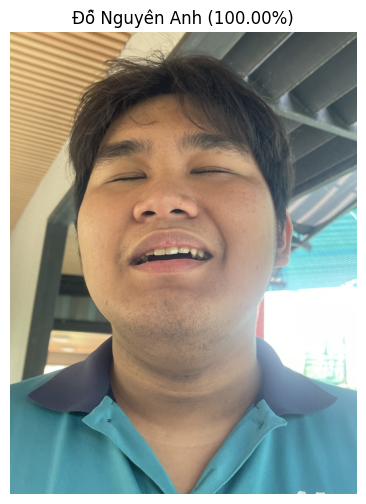

Đỗ Nguyên Anh


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = "/content/drive/MyDrive/BT tuần 7 AI/Đỗ Nguyên Anh/IMG_4710.jpg"

img_display = plt.imread(img_path)

img = image.load_img(
    img_path,
    target_size=(200,200)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction) * 100

plt.figure(figsize=(6,6))
plt.imshow(img_display)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print(predicted_class)
